For plotting at the same variable set at different depths

In [10]:
import ModelViz
from sklearn.cluster import KMeans
from sklearn import metrics
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from matplotlib.transforms import ScaledTranslation
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import glob
import matplotlib.ticker as mticker

    
from netCDF4 import Dataset as DS

import cmocean


Create an instance of the ModelViz class, then use the functions to 
* `load_data / load_mfdata` to load data
* `load_grid` to load grid information
* `summarise_features` to sum sets of variables together
* `preprocess` to strip boundary and normalise 
* `make_tsds` to reshape data into a time series data set (tsds)
* `load_tsds` to load an existing time series data set from csv
* `train` to create a clustering model
* `load_model` to load an existing model
* `predict` to create predictions based on a tsds and model
* `get_cluster_info` to summarise predictions and calcuate mean/std dev for each cluster
* `plot_map` to plot the cluster output as a map
* `plot_ts` to plot time series for each cluster


## Train the model

Create an instace of ModelViz for the training data, read in that data and grid info
Combine variables and preprocess - stripping the boundary layers and normalising
Make the dataset by reshaping the data into the form needed 
Fit the model

In [3]:
def cluster_var_names(classification,depth):
    train = ModelViz.ModelViz()

    # weird formatting of my data....
    train.x_strip = slice(15,-15)
    train.y_strip = slice(15,-15)
    train.n_init = 100 #0
    train.seed = 800
    train.norm = 'stdev'
    if classification == 'biogeo':
        train.cluster_vars = ['N1_p','N3_n','N4_n','N5_s','O2_o','O3_c','O3_TA']  #['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s']
        train.plot_vars={'N1_p':'Phosphate','N3_n':'Nitrate','O2_o':'Oxygen','O3_c':'DIC','O3_TA':'Alk.', 'N4_n':'Ammon.', 'N5_s':'Silicate'}
    if classification == 'ecosys':
        train.cluster_vars = ['Phytoplankton','Zooplankton','DOC','POC','B1_c']
        train.plot_vars={'Phytoplankton':'Phytoplankton','Zooplankton':'Zooplankton','DOC':'DOC','POC':'POC','B1_c':'B1_c'}
    if classification == 'biogeo-ecosys':
        train.cluster_vars =  ['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s','Phytoplankton','Zooplankton','DOC','POC','B1_c']
    if classification == 'physics':
        train.cluster_vars = ['votemper','vosaline','mldr10_1','PAR']
        train.plot_vars={'votemper':'Temperature','vosaline':'Salinity','mldr10_1':'Mixed layer\ndepth','PAR':'Surface\nirradiance'}
    
    if classification == 'biogeo-ecosys':
        filename = glob.glob('/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_biogeo.nc')
        filename.extend(glob.glob('/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_ecosys.nc'))
    else:
        filename = glob.glob('/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc')

    #train.load_mfdata(filename)
    train.ds = xr.open_mfdataset(filename).drop_dims('axis_nbounds', errors='ignore')

    train.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

    train.preprocess(do_slice=False)     
    train.make_tsds()
    train.train(n_clusters=6, save=False,model_name = 'kmeans')
    train.predict()
    train.get_cluster_info(save=False)
    return train
        


In [12]:
classification = 'biogeo'

depth = 'surface'
train1 = cluster_var_names(classification,depth)

depth = 'bottom'
train2 = cluster_var_names(classification,depth)

depth = 'DA'
train3 = cluster_var_names(classification,depth)

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 59.02it/s]


Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 63.69it/s]


Processing N4_n


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 65.75it/s]


Processing O3_c


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 65.52it/s]


Processing O3_TA


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 66.09it/s]


Produce a prediction of the training data

Create cluster dataset with the classification map, plus mean and std dev time series for each cluster

Plot data

In [11]:
vibrant = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']
bright = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']

def plot_map(ax,train,hex_list,title_val,label,left_tick,bottom_tick):
    train.cmap = train.make_cmap(hex_list)
    ax.pcolormesh(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map, cmap=train.cmap)
    
    # marking out shelf edge
    nc=DS('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc') #'/data/sthenno1/scratch/hpo/LOCATE/mesh_mask.nc')
    lon=nc.variables['nav_lon']
    lat=nc.variables['nav_lat']
    bath=nc.variables['gdept_0'][:,-1]
    #not sure what this was doing
    bath_data=np.ma.masked_where(bath[0]==10.1,bath[0])

    extent=[-18.22224,10.11081,41.06672,64.0012]
    ax.set_extent(extent)
    # add contours
    CS=ax.contour(lon[:],lat[:],bath_data, levels=[200],colors='0.6')
    ax.clabel(CS, inline=True, fontsize=8)
    
    ax.add_feature(NaturalEarthFeature(category="physical", facecolor=[0.9, 0.9, 0.9], name="coastline", scale="50m"),
                   edgecolor="gray")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.0, color="gray", linestyle="-")
    gl.top_labels = False
    gl.bottom_labels = bottom_tick
    gl.right_labels = False
    gl.left_labels = left_tick
    gl.ylocator = mticker.FixedLocator([45,50,55,60])
    ax.set_aspect("equal")
    ax.set_title(title_val)
    ax.text(
    0.1, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize='large', va='bottom')









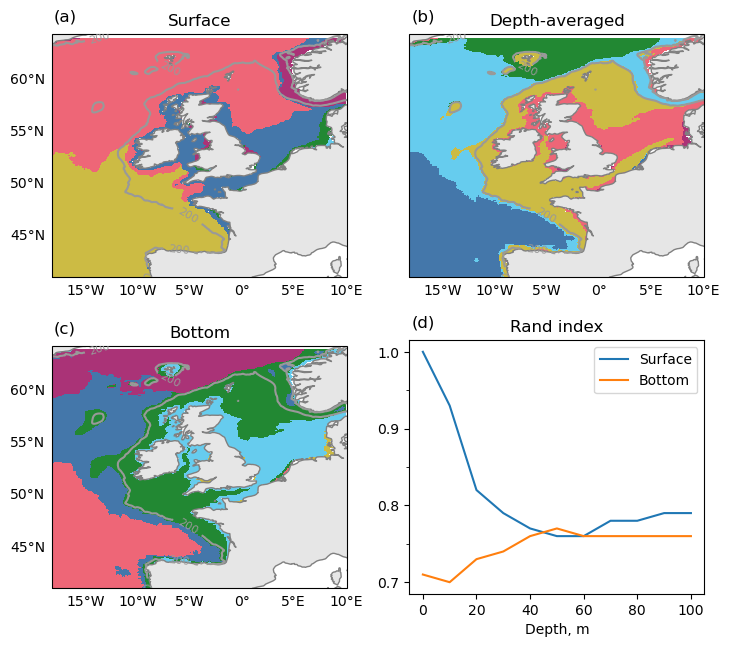

In [14]:


#fig = plt.figure(layout="constrained",figsize=[13.5,7.75])
fig = plt.figure(layout="constrained",figsize=[7.4,6.6])

gs = GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'Surface','(a)',True,True)
ax2 = fig.add_subplot(gs[0, 2:4], projection = ccrs.PlateCarree())
plot_map(ax2,train3,bright,'Depth-averaged','(b)',False,True)
ax3 = fig.add_subplot(gs[1, 0:2], projection = ccrs.PlateCarree())
plot_map(ax3,train2,bright,'Bottom','(c)',True,True)
depth = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rand_index_surface = [1, 0.93, 0.82, 0.79, 0.77, 0.76, 0.76, 0.78, 0.78, 0.79, 0.79]
rand_index_bottom = [0.71, 0.70, 0.73, 0.74, 0.76, 0.77, 0.76, 0.76, 0.76, 0.76, 0.76]
ax4 = fig.add_subplot(gs[1, 2:4])

# Set ax2 position to match ax1's size

# Adjust the figure size to fit both subplots
#fig.set_size_inches(8, 2 * pos1.height * fig.dpi)

ax4.plot(depth, rand_index_surface,label='Surface')
ax4.plot(depth, rand_index_bottom,label='Bottom')
ax4.set_xlabel('Depth, m')
plt.legend()
ax4.set_title('Rand index')
ax4.text(
0.1, 1.0, '(d)', transform=(
    ax4.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
fontsize='large', va='bottom')
ax4.set_yticks([0.7,0.8,0.9,1])
ax4.set_yticks([0.75,0.85,0.95],minor=True)

#plt.savefig('rand_depth.png')
#plt.show()
plt.tight_layout()
plt.savefig('biogeo_w_shelf.png')

In [55]:
def get_ax_size(ax):
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    width, height = bbox.width, bbox.height
    width *= fig.dpi
    height *= fig.dpi
    return width, height

data = np.arange(9).reshape((3, 3))
fig = plt.figure(figsize=(8,6), dpi=80)
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
fig.add_axes(ax)
ax.imshow(data, aspect='equal')
print(get_ax_size(ax))
# (640.0, 480.0)
plt.savefig('/tmp/test.png', dpi=80)

In [10]:
print(metrics.rand_score(train1.labels,train3.labels))

print(metrics.rand_score(train2.labels,train3.labels))

print(metrics.rand_score(train1.labels,train2.labels))



0.7192282439661745
0.8796634417617964
0.7073584970160254


In [15]:
classification = 'ecosys'
depth = 'surface'

train1 = cluster_var_names(classification,depth)

classification = 'ecosys'
depth = 'bottom'

train2 = cluster_var_names(classification,depth)

classification = 'ecosys'
depth = 'DI'

train3 = cluster_var_names(classification,depth)

classification = 'ecosys'
depth = 'DA'

train4 = cluster_var_names(classification,depth)

Processing Phytoplankton


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 60.98it/s]


Processing Zooplankton


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 67.52it/s]


Processing DOC


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 64.35it/s]


Processing POC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 61.62it/s]


Processing B1_c


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 60.31it/s]


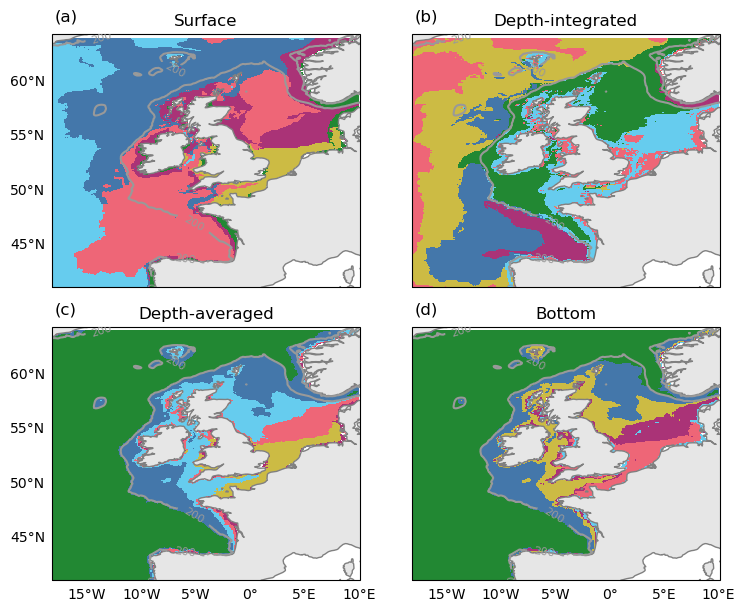

In [16]:
fig = plt.figure(layout="constrained",figsize=[7.4,6])

gs = GridSpec(2, 2, figure=fig,hspace=0.05)
ax1 = fig.add_subplot(gs[0, 0], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'Surface','(a)',True,False)
ax2 = fig.add_subplot(gs[0, 1], projection = ccrs.PlateCarree())
plot_map(ax2,train3,bright,'Depth-integrated','(b)',False,False)
ax3 = fig.add_subplot(gs[1, 0], projection = ccrs.PlateCarree())
plot_map(ax3,train4,bright,'Depth-averaged','(c)',True,True)
ax4 = fig.add_subplot(gs[1, 1], projection = ccrs.PlateCarree())
plot_map(ax4,train2,bright,'Bottom','(d)',False,True)

#plt.show()

#plt.tight_layout()
plt.savefig('ecosys_w_shelf.png')

In [6]:
classification = 'biogeo-ecosys'
depth = 'surface'

train1 = cluster_var_names(classification,depth)

Processing N1_p


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 60.94it/s]


Processing N3_n


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 65.68it/s]


Processing O2_o


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 66.83it/s]


Processing POC


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 67.12it/s]


Processing B1_c


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 67.98it/s]


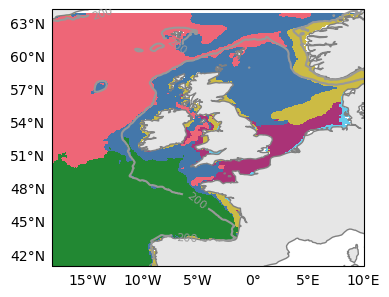

In [9]:
fig = plt.figure(layout="constrained",figsize=[4,4])

gs = GridSpec(1, 1, figure=fig)
ax1 = fig.add_subplot(gs[0, 0], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'','',True,True)

#plt.show()

plt.tight_layout()
plt.savefig('biogeo-ecosys.png')

In [17]:
classification = 'physics'
depth = 'surface'

train1 = cluster_var_names(classification,depth)

classification = 'physics'
depth = 'bottom'

train2 = cluster_var_names(classification,depth)

classification = 'physics'
depth = 'DA'

train3 = cluster_var_names(classification,depth)

Processing votemper


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 62.25it/s]


Processing vosaline


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 64.03it/s]


Processing mldr10_1


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 61.21it/s]


Processing mldr10_1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 64.90it/s]


Processing PAR


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 57.84it/s]


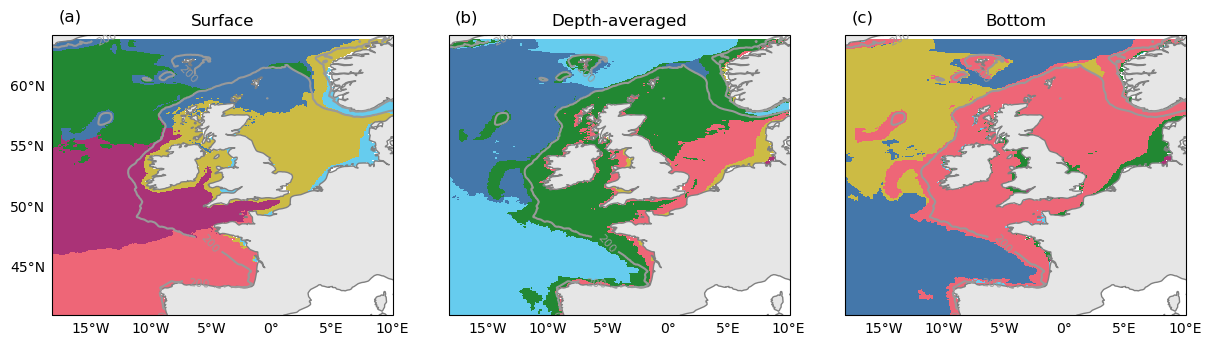

In [19]:
fig = plt.figure(layout="constrained",figsize=[12,5])

gs = GridSpec(1, 3, figure=fig,wspace=0.1)
ax1 = fig.add_subplot(gs[0], projection = ccrs.PlateCarree())
plot_map(ax1,train1,bright,'Surface','(a)',True,True)
ax2 = fig.add_subplot(gs[1], projection = ccrs.PlateCarree())
plot_map(ax2,train3,bright,'Depth-averaged','(b)',False,True)
ax3 = fig.add_subplot(gs[2], projection = ccrs.PlateCarree())
plot_map(ax3,train2,bright,'Bottom','(c)',False,True)

#plt.show()

#plt.tight_layout()
plt.savefig('physics-w_shelf.png')